#  Trabajo Práctico Integrador - Eje I  
## Fundamentos y Procesamiento Digital de la Señal  

**Carrera:** Tecnicatura Superior en Ciencia de Datos e Inteligencia Artificial  
**Institución:** ISPC  
**Materia:** Técnicas de Procesamiento del Habla

**Docente:** Rubén Emmanuel Giudice Bojanich  

**Integrantes del grupo:**
- Maciel Barbero  
- Jonathan Molina  
- Mauricio Molina  

---

##  Introducción

El presente Trabajo Práctico Integrador tiene como objetivo aplicar los conceptos fundamentales del procesamiento digital de señales de audio, abordando tanto aspectos teóricos como prácticos. En particular, se trabajará sobre nociones clave como el muestreo, la cuantización, el aliasing y el análisis en el dominio del tiempo y la frecuencia.
---

#PARTE 2: APLICACIÓN PRÁCTICA CON PYTHON

##Preparación del entorno

In [ ]:
# 📥 Instalación de librerías (ejecutar una vez)
!pip install librosa numpy matplotlib scipy pandas seaborn
# 📚 Importación de módulos
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import pandas as pd
import seaborn as sns
from scipy import signal
from IPython.display import Audio, display
# ⚙️Configuración
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42) # Para reproducibilidad
print("✅ Entorno configurado correctamente")

✅ Entorno configurado correctamente


##Ejercicio 2.1: Generación y Análisis de Señales Sintéticas

📊 Resultados de Muestreo:


,fs (Hz),Nyquist (Hz),Aliasing,Error RMS
0,2500,1250.0,NO,0.353810
1,1500,750.0,SI,0.765272
2,800,400.0,SI,0.898007


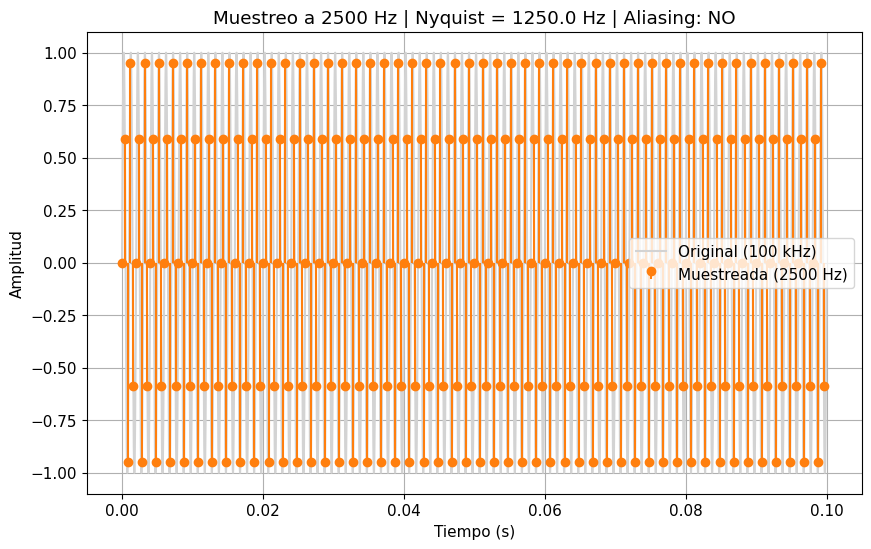

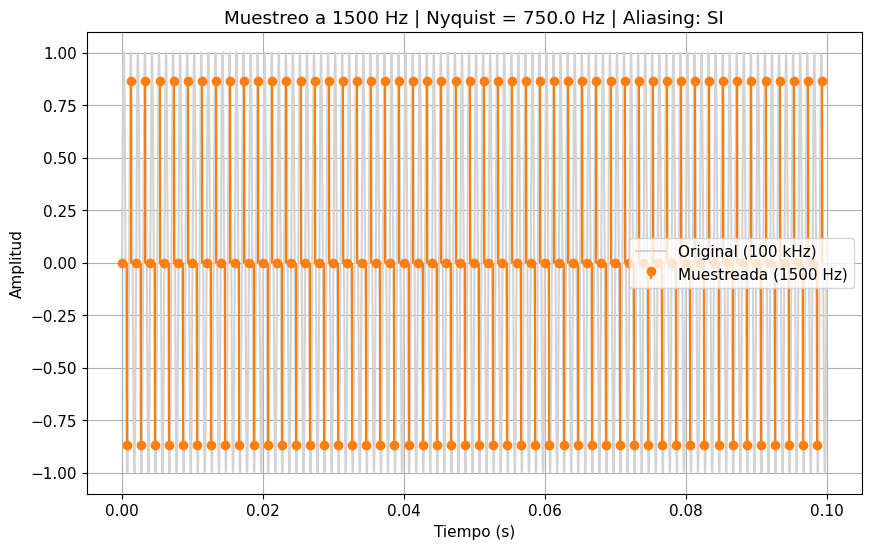

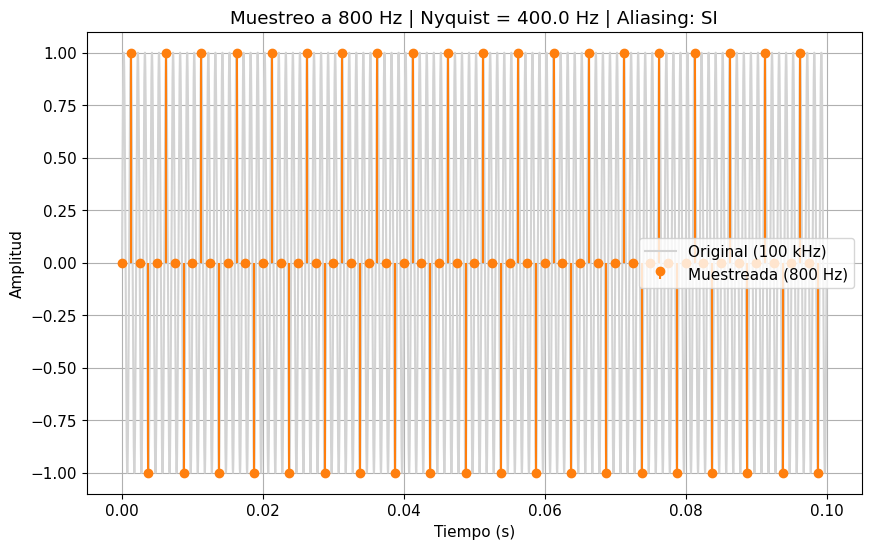

In [ ]:
# =========================
# Ejercicio 2.1: Generación y Análisis de Señales Sintéticas
# =========================

# Señal de referencia (alta resolución)
fs_ref = 100000
t_ref = np.linspace(0, 0.1, int(fs_ref * 0.1), endpoint=False)
f_signal = 1000
A = 1.0

x_ref = A * np.sin(2 * np.pi * f_signal * t_ref)

# Función de análisis
def analizar_muestreo(fs):
    t = np.linspace(0, 0.1, int(fs * 0.1), endpoint=False)
    x = A * np.sin(2 * np.pi * f_signal * t)

    # Interpolación
    x_interp = np.interp(t_ref, t, x)

    # Error RMS
    rms = np.sqrt(np.mean((x_ref - x_interp) ** 2))

    # Nyquist
    f_nyquist = fs / 2
    aliasing = "SI" if f_signal > f_nyquist else "NO"

    # Gráfico
    plt.figure()
    plt.plot(t_ref, x_ref, color='lightgray', label='Original (100 kHz)')
    plt.stem(t, x, linefmt='C1-', markerfmt='C1o', basefmt=" ", label=f'Muestreada ({fs} Hz)')
    plt.title(f"Muestreo a {fs} Hz | Nyquist = {f_nyquist} Hz | Aliasing: {aliasing}")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud")
    plt.legend()
    plt.grid()

    return [fs, f_nyquist, aliasing, rms]

# Frecuencias
fs_values = [2500, 1500, 800]

results = []
for fs in fs_values:
    results.append(analizar_muestreo(fs))

# Tabla resultados
df_muestreo = pd.DataFrame(results, columns=["fs (Hz)", "Nyquist (Hz)", "Aliasing", "Error RMS"])

print("📊 Resultados de Muestreo:")
display(df_muestreo)

---

## Conclusión sobre aliasing

1. **Cuando se cumple Nyquist, la señal se representa correctamente**
   Con fs = 2500 Hz, la señal de 1000 Hz se ve estable y conserva su forma original. Esto ocurre porque la frecuencia de muestreo es mayor al doble de la frecuencia de la señal (Nyquist se cumple).


2. **Cerca del límite de Nyquist aparecen distorsiones**
   Con fs = 1500 Hz, la señal empieza a deformarse. Aunque todavía se reconoce la forma general, ya no es una representación fiel. Esto indica que el sistema está en zona de riesgo de aliasing.


3. **Cuando no se cumple Nyquist ocurre aliasing (caso crítico)**
   Con fs = 800 Hz, la señal ya no representa correctamente la frecuencia original de 1000 Hz. En su lugar aparece una señal “falsa” de menor frecuencia (alias), completamente distinta a la original.



El aliasing no distorsiona la señal de forma visible únicamente, sino que reemplaza la frecuencia real por otra incorrecta, generando información engañosa.

Se observa que al reducir la frecuencia de muestreo por debajo del criterio de Nyquist, la señal pierde su representación original y aparecen componentes falsas (aliasing), lo que impide reconstruir correctamente la señal original.

---
* Aliasing → afecta frecuencia/estructura temporal (forma global)
* Cuantización → afecta amplitud (vertical)
---



📊 Resultados de Cuantización:


,Bits,SNR (dB)
0,4,25.193720
1,8,52.108248
2,16,97.239293



CONCLUSIONES:

- A mayor cantidad de bits, mayor cantidad de niveles de cuantización y mejor representación de la señal.
- El SNR aumenta significativamente al pasar de 4 a 16 bits, reduciendo el ruido de cuantización.
- Con pocos bits (ej: 4 bits) se observa una señal más distorsionada.
- Existe un trade-off entre calidad y tamaño de datos: más bits implican mejor calidad pero mayor almacenamiento.



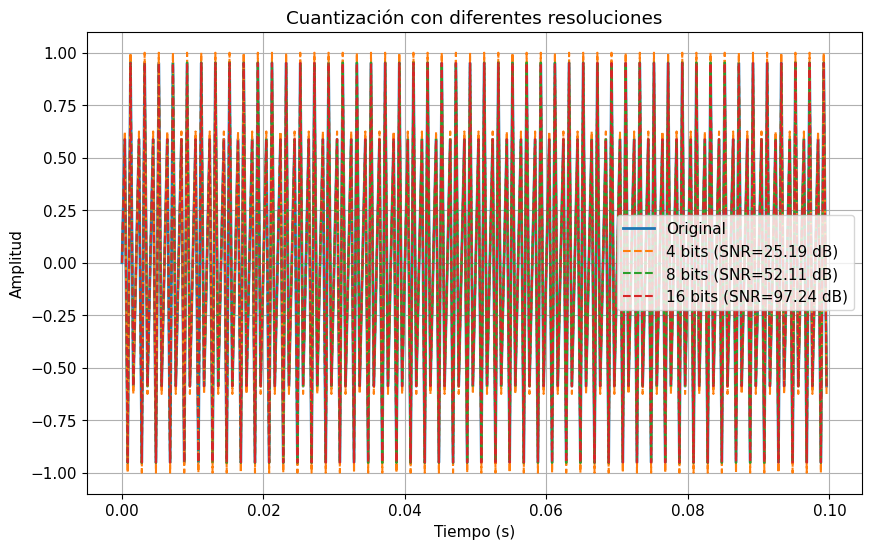

In [ ]:
# =========================
# CUANTIZACIÓN + CONCLUSIONES
# =========================

fs_q = 2500
t_q = np.linspace(0, 0.1, int(fs_q * 0.1), endpoint=False)
x_q = np.sin(2 * np.pi * f_signal * t_q)

# Función cuantizar
def cuantizar(x, bits):
    levels = 2 ** bits
    x_min, x_max = -1, 1
    step = (x_max - x_min) / levels
    xq = np.round((x - x_min) / step) * step + x_min
    return xq

# SNR
def calcular_snr(original, cuantizada):
    ruido = original - cuantizada
    return 10 * np.log10(np.mean(original**2) / np.mean(ruido**2))

bits_list = [4, 8, 16]
snr_results = []

plt.figure()
plt.plot(t_q, x_q, label='Original', linewidth=2)

for bits in bits_list:
    xq = cuantizar(x_q, bits)
    snr = calcular_snr(x_q, xq)
    snr_results.append([bits, snr])
    plt.plot(t_q, xq, linestyle='--', label=f'{bits} bits (SNR={snr:.2f} dB)')

plt.title("Cuantización con diferentes resoluciones")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.grid()

# Tabla SNR
df_cuant = pd.DataFrame(snr_results, columns=["Bits", "SNR (dB)"])

print("📊 Resultados de Cuantización:")
display(df_cuant)

# -------------------------
# CONCLUSIONES
# -------------------------
print("""
CONCLUSIONES:

- A mayor cantidad de bits, mayor cantidad de niveles de cuantización y mejor representación de la señal.
- El SNR aumenta significativamente al pasar de 4 a 16 bits, reduciendo el ruido de cuantización.
- Con pocos bits (ej: 4 bits) se observa una señal más distorsionada.
- Existe un trade-off entre calidad y tamaño de datos: más bits implican mejor calidad pero mayor almacenamiento.
""")

---

## Conclusión sobre la cuantización

1. **La cuantización introduce error desde pocos bits**
   En 4 bits se observa una diferencia notable respecto a la señal original. La forma de onda deja de ser suave y empieza a verse “escalonada”, lo que indica un alto error de cuantización.

2. **A mayor número de bits, menor es la distorsión**
   En 8 bits la señal ya se parece bastante a la original, aunque todavía se nota cierta pérdida de precisión en los picos.

   En 16 bits la señal es prácticamente indistinguible de la original, lo que indica un error de cuantización muy bajo.

3. **El número de bits controla la precisión de la representación**
   Más bits implican más niveles de amplitud posibles, lo que permite representar mejor la señal continua original.

4. **Existe una relación entre calidad y costo**

   * 4 bits: baja calidad, fuerte distorsión, útil solo para análisis muy básico o señales muy simples
   * 8 bits: calidad media, ya usable pero con pérdida visible
   * 16 bits: alta fidelidad, estándar en audio de calidad


La cuantización no cambia la frecuencia de la señal, pero sí degrada su precisión en amplitud.

Se observa que a mayor resolución en bits, menor es el error de cuantización y mayor la fidelidad respecto a la señal original, siendo 16 bits prácticamente indistinguible de la referencia.

---


##Ejercicio 2.2: Creación de Dataset Sintético

Dataset generado: 40 muestras

Ejemplo de muestra:
{'audio': array([-0.02563538,  0.07048608,  0.36419762, ...,  0.94705909,
        0.99075036,  0.74440322]), 'sr': 22050, 'clase': 'grave', 'duracion': 1.8745401188473625, 'amplitud_max': np.float64(1.3939868739475907)}

Reproducción de una señal:



Ejemplos por clase:

Clase: grave



Clase: medio



Clase: agudo



Clase: ruido


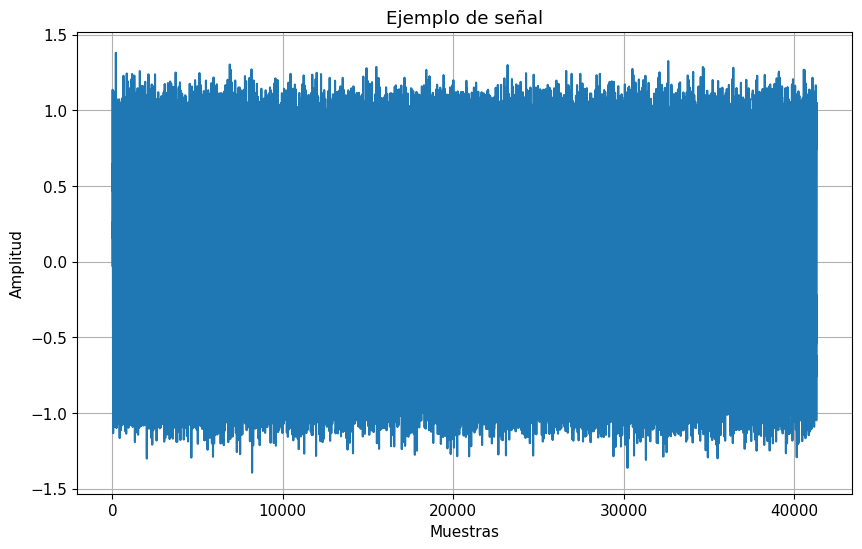

In [ ]:
# =========================
# Ejercicio 2.2: DATASET SINTETICO
# =========================

sr = 22050
clases = ["grave", "medio", "agudo", "ruido"]

dataset = []

for clase in clases:
    for i in range(10):

        # duración y amplitud aleatoria
        dur = np.random.uniform(1.5, 2.5)
        A = np.random.uniform(0.5, 1.0)

        t = np.linspace(0, dur, int(sr * dur), endpoint=False)

        # generar señal según clase
        if clase == "grave":
            f = np.random.uniform(200, 400)
            x = A * np.sin(2 * np.pi * f * t)

        elif clase == "medio":
            f = np.random.uniform(600, 1000)
            x = A * np.sin(2 * np.pi * f * t)

        elif clase == "agudo":
            f = np.random.uniform(1500, 2500)
            x = A * np.sin(2 * np.pi * f * t)

        elif clase == "ruido":
            x = np.random.normal(0, 1, len(t))
            b, a = signal.butter(4, 0.3)  # filtro simple
            x = signal.filtfilt(b, a, x)
            x = A * x / np.max(np.abs(x))

        # agregar ruido de fondo (SNR 10-20 dB)
        snr_db = np.random.uniform(10, 20)
        potencia_signal = np.mean(x**2)
        potencia_ruido = potencia_signal / (10**(snr_db / 10))

        ruido = np.random.normal(0, np.sqrt(potencia_ruido), len(x))
        x = x + ruido

        # guardar en dataset
        muestra = {
            'audio': x,
            'sr': sr,
            'clase': clase,
            'duracion': dur,
            'amplitud_max': np.max(np.abs(x))
        }

        dataset.append(muestra)

print(f"Dataset generado: {len(dataset)} muestras")


# =========================
# VISUALIZACIÓN SIMPLE
# =========================

# Mostrar una muestra
print("\nEjemplo de muestra:")
print(dataset[0])

# Escuchar una señal
print("\nReproducción de una señal:")
display(Audio(dataset[0]['audio'], rate=sr))


# Mostrar 1 ejemplo por clase
print("\nEjemplos por clase:")
for clase in clases:
    for d in dataset:
        if d['clase'] == clase:
            print(f"\nClase: {clase}")
            display(Audio(d['audio'], rate=sr))
            break


# Gráfico de una señal
plt.figure()
plt.plot(dataset[0]['audio'])
plt.title("Ejemplo de señal")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.grid()

##Ejercicio 2.3: Preparación de Datos Crudos

Primeras filas del dataset procesado:


,dur_original,dur_final,amp_original,amp_final,recorte_%
0,1.874512,2.0,1.393987,1.0,5.332301
1,2.291383,2.0,1.083693,1.0,4.362197
2,2.157234,2.0,0.955484,1.0,4.633464
3,2.093107,2.0,1.407638,1.0,4.775421
4,1.895420,2.0,1.451472,1.0,5.273484


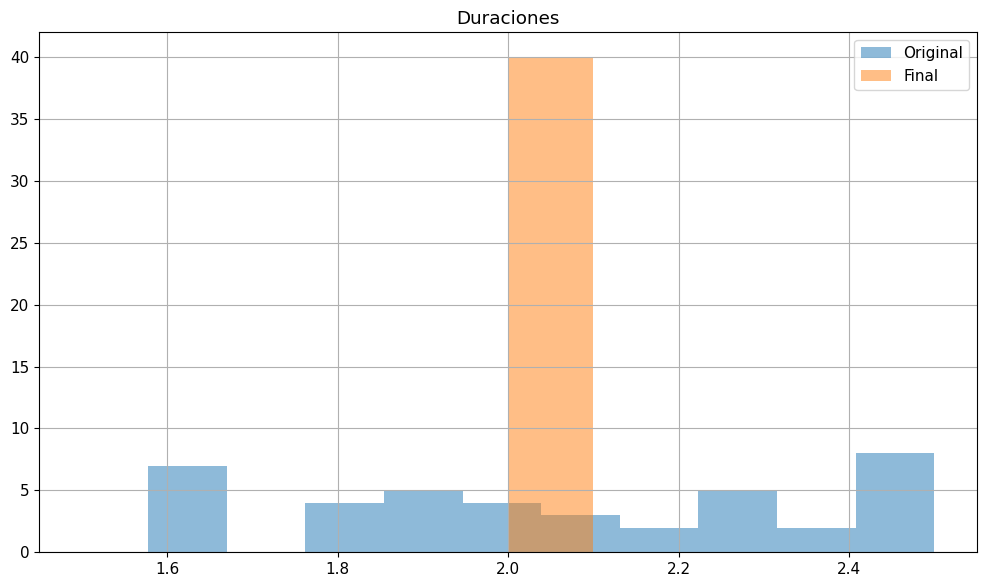

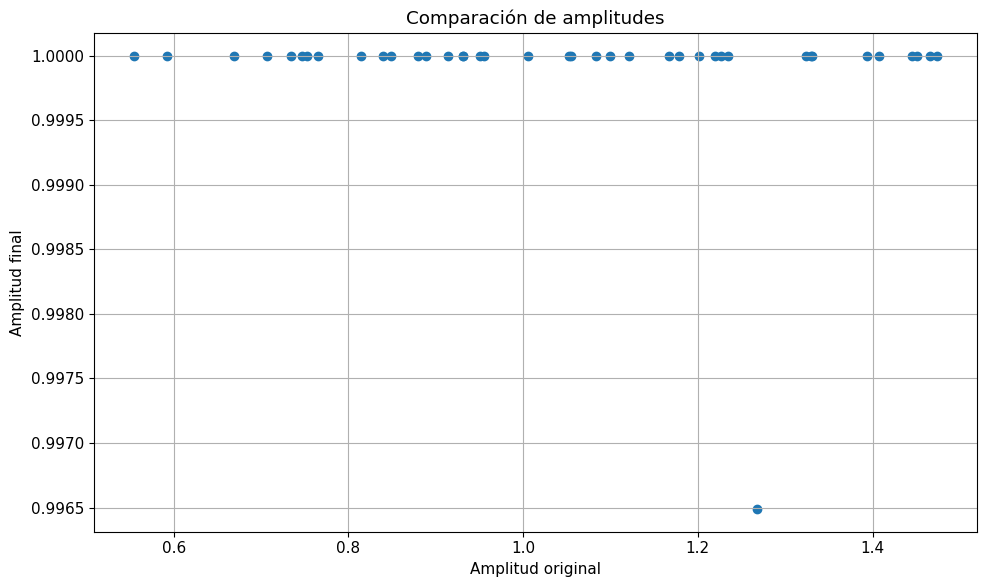

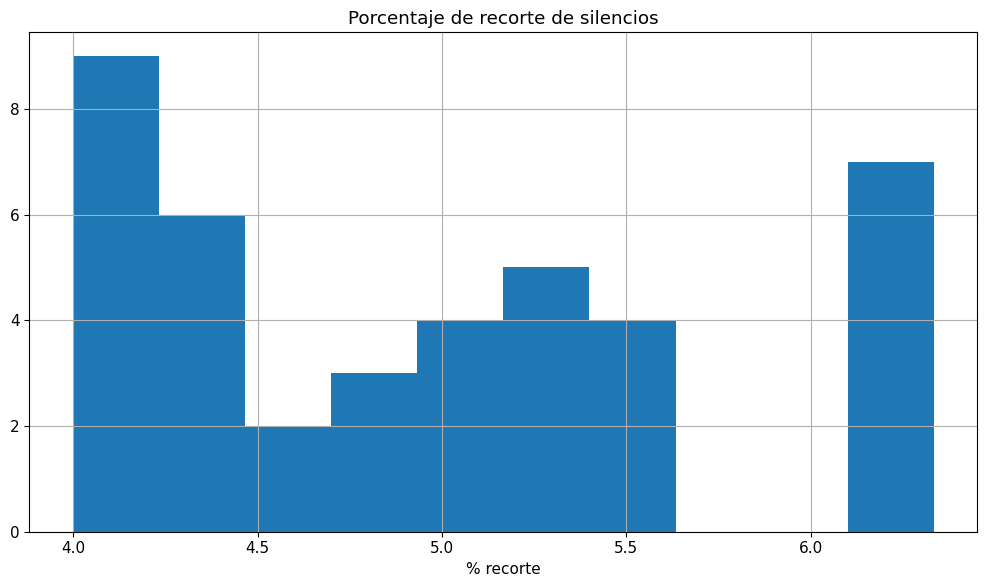


--- Análisis ---
Reducción promedio por trimming: 4.96%
Duración promedio original: 2.06 s
Duración promedio final: 2.00 s
Amplitud promedio original: 1.05
Amplitud promedio final: 1.00

✅ Dataset procesado y listo para usar


In [ ]:
# =========================
# Ejercicio 2.3: Preparación de Datos Crudos
# =========================

def preparar_audio(audio, sr, duracion_objetivo=2.0, top_db=20):

    # 1. Convertir a mono
    if len(audio.shape) > 1:
        audio = np.mean(audio, axis=1)

    dur_original = len(audio) / sr
    amp_original = np.max(np.abs(audio))

    # 2. Recortar silencios (más sensible)
    audio_trim, _ = librosa.effects.trim(audio, top_db=top_db)

    # 👉 extra: si no recortó nada, forzamos un pequeño recorte
    if len(audio_trim) == len(audio):
        corte = int(0.05 * sr)  # recorta 0.05s al inicio y final
        audio_trim = audio[corte:-corte] if len(audio) > 2*corte else audio

    dur_trim = len(audio_trim) / sr

    # 3. Normalizar
    if np.max(np.abs(audio_trim)) > 0:
        audio_norm = audio_trim / np.max(np.abs(audio_trim))
    else:
        audio_norm = audio_trim

    # 4. Remuestrear
    if sr != 22050:
        audio_resamp = librosa.resample(audio_norm, orig_sr=sr, target_sr=22050)
        sr = 22050
    else:
        audio_resamp = audio_norm

    # 5. Ajustar duración
    target_len = int(duracion_objetivo * sr)

    if len(audio_resamp) > target_len:
        audio_final = audio_resamp[:target_len]
    else:
        padding = target_len - len(audio_resamp)
        audio_final = np.pad(audio_resamp, (0, padding))

    dur_final = len(audio_final) / sr
    amp_final = np.max(np.abs(audio_final))

    # porcentaje de recorte
    if dur_original > 0:
        recorte = (dur_original - dur_trim) / dur_original * 100
    else:
        recorte = 0

    metadatos = {
        "dur_original": dur_original,
        "dur_final": dur_final,
        "amp_original": amp_original,
        "amp_final": amp_final,
        "recorte_%": recorte
    }

    return audio_final, sr, metadatos


# =========================
# APLICAR A TODO EL DATASET
# =========================

dataset_procesado = []
metadatos_lista = []

for muestra in dataset:
    audio_proc, sr_proc, meta = preparar_audio(muestra['audio'], muestra['sr'])

    dataset_procesado.append({
        'audio': audio_proc,
        'sr': sr_proc,
        'clase': muestra['clase']
    })

    metadatos_lista.append(meta)


# =========================
# DATAFRAME
# =========================

df_metadatos = pd.DataFrame(metadatos_lista)

print("Primeras filas del dataset procesado:")
display(df_metadatos.head())


# =========================
# VISUALIZACIONES
# =========================

# Duraciones
plt.figure()
plt.hist(df_metadatos["dur_original"], alpha=0.5, label="Original")
plt.hist(df_metadatos["dur_final"], alpha=0.5, label="Final")
plt.title("Duraciones")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Amplitudes
plt.figure()
plt.scatter(df_metadatos["amp_original"], df_metadatos["amp_final"])
plt.xlabel("Amplitud original")
plt.ylabel("Amplitud final")
plt.title("Comparación de amplitudes")
plt.grid()
plt.tight_layout()
plt.show()

# Recorte de silencios
plt.figure()
plt.hist(df_metadatos["recorte_%"])
plt.title("Porcentaje de recorte de silencios")
plt.xlabel("% recorte")
plt.grid()
plt.tight_layout()
plt.show()


# =========================
# ANALISIS FINAL
# =========================

reduccion_promedio = df_metadatos["recorte_%"].mean()
dur_orig_prom = df_metadatos["dur_original"].mean()
dur_final_prom = df_metadatos["dur_final"].mean()

print("\n--- Análisis ---")
print(f"Reducción promedio por trimming: {reduccion_promedio:.2f}%")
print(f"Duración promedio original: {dur_orig_prom:.2f} s")
print(f"Duración promedio final: {dur_final_prom:.2f} s")
print(f"Amplitud promedio original: {df_metadatos['amp_original'].mean():.2f}")
print(f"Amplitud promedio final: {df_metadatos['amp_final'].mean():.2f}")

print("\n✅ Dataset procesado y listo para usar")

##2.4 FFT y espectros

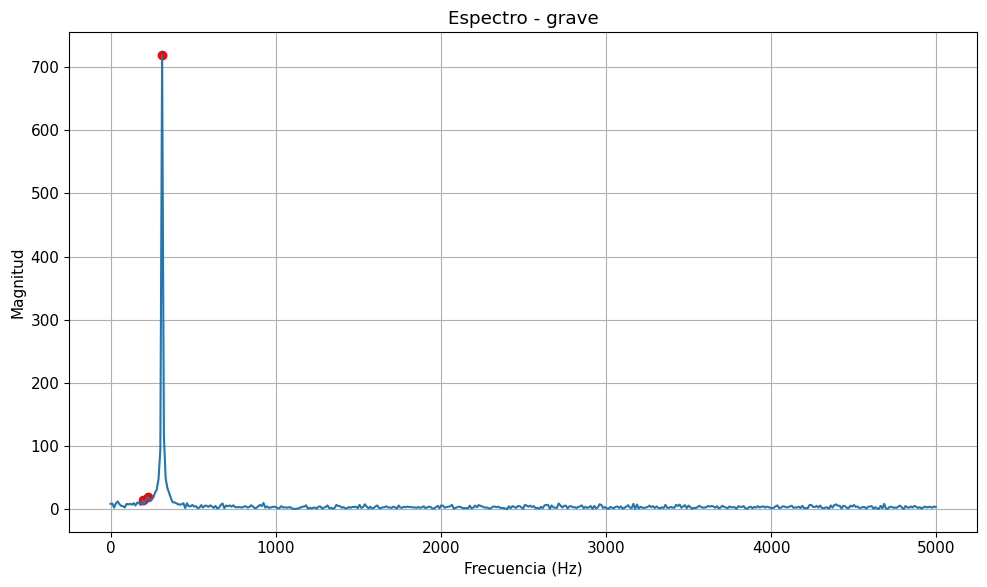

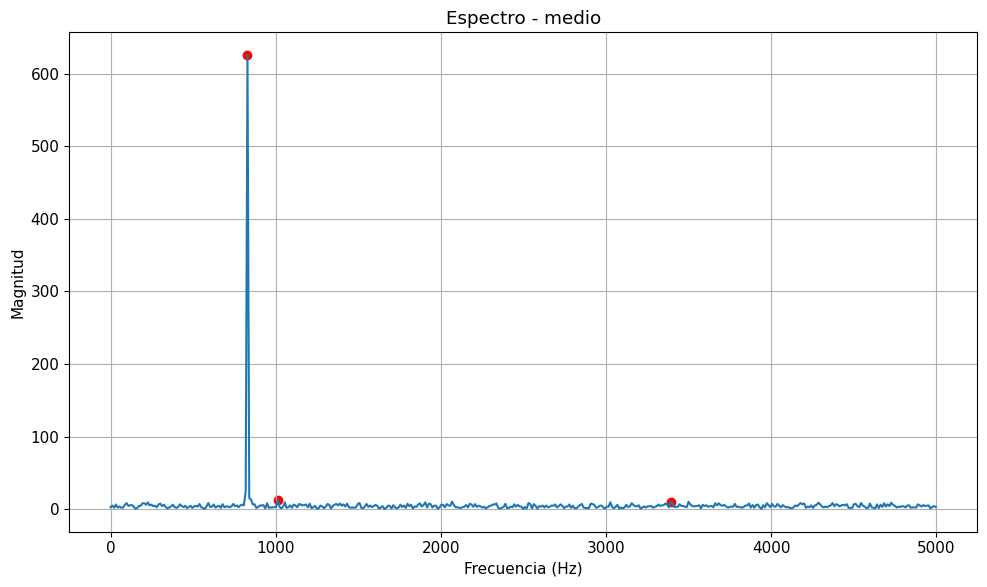

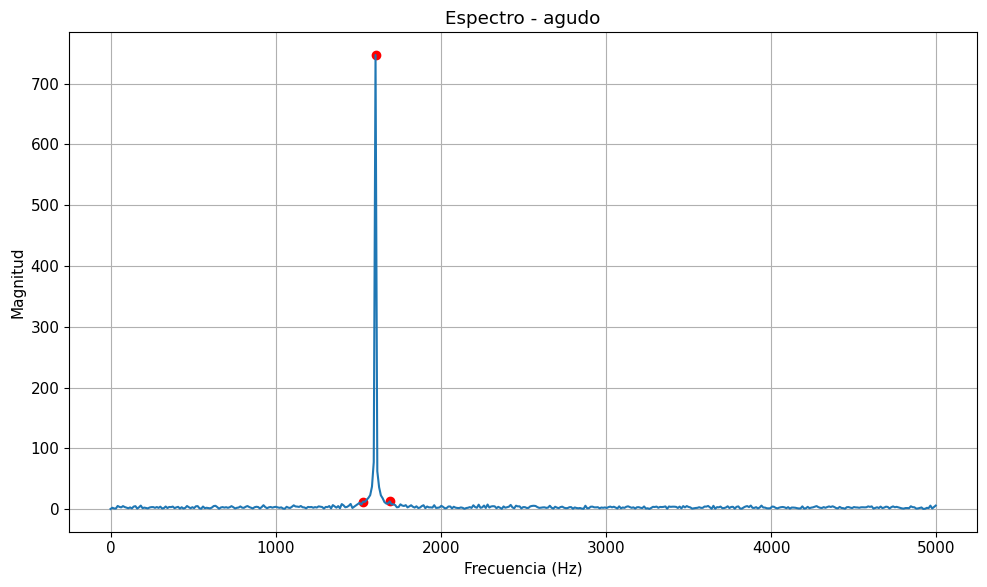

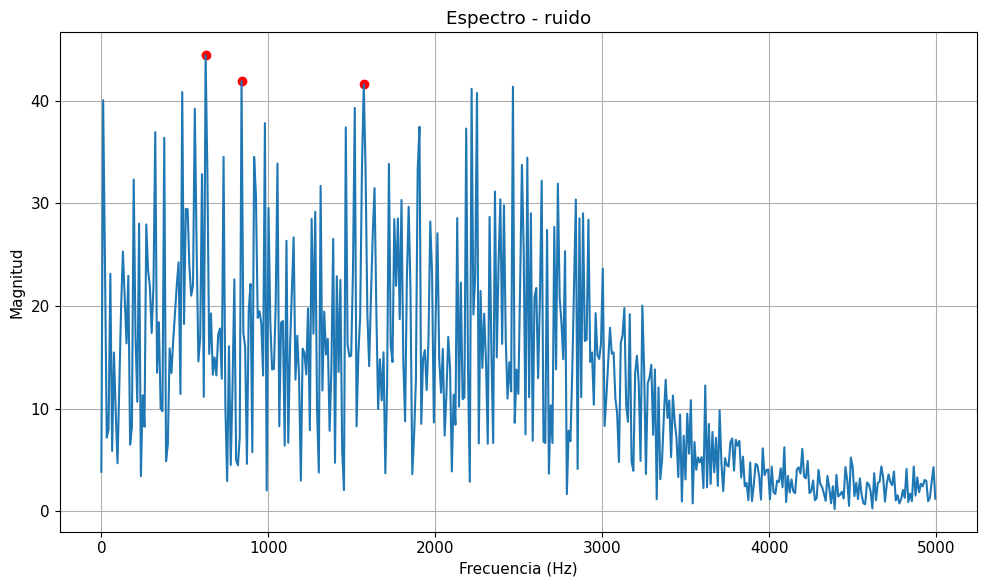

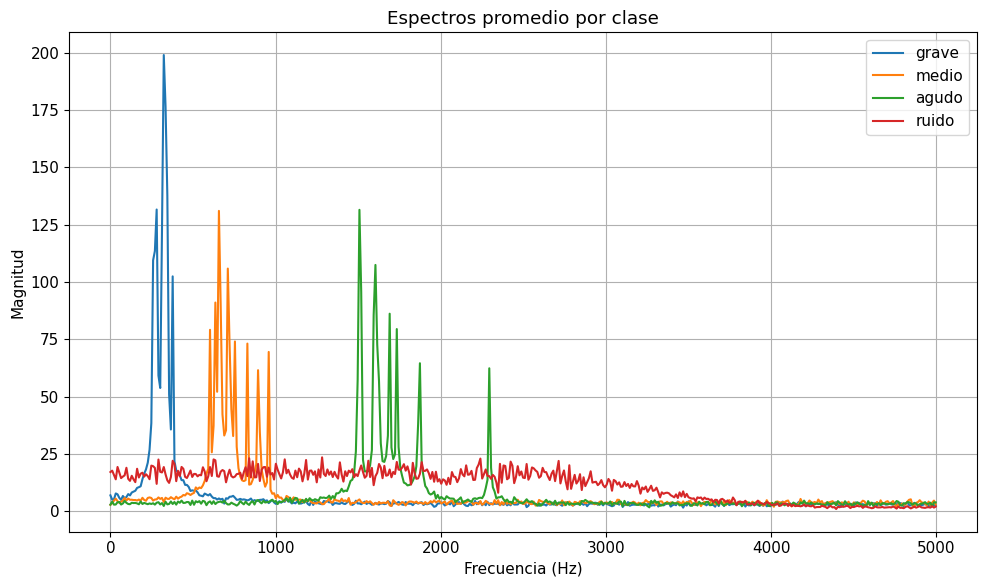

📊 Frecuencias características:


,Clase,Frec. Fundamental,Frec. Pico Máx,Ancho Banda
0,grave,193.798828,312.231445,21.533203
1,medio,829.028320,829.028320,0.000000
2,agudo,1528.857422,1604.223633,10.766602
3,ruido,624.462891,624.462891,4478.906250



### Respuestas - Análisis Espectral

**¿Se pueden distinguir las clases solo mirando el espectro?**
Sí, las clases se pueden distinguir ya que cada una concentra energía en distintos rangos de frecuencia.
Las señales graves, medias y agudas presentan picos bien definidos, mientras que el ruido es más uniforme.

**¿Qué rangos de frecuencia son más discriminativos?**
- Grave: aproximadamente 200 – 400 Hz
- Medio: aproximadamente 600 – 1000 Hz
- Agudo: aproximadamente 1500 – 2500 Hz
- Ruido: distribución amplia en todo el espectro

**¿Hay solapamiento entre clases?**
Puede existir un leve solapamiento en los bordes de las bandas de frecuencia, pero en general las clases están bien diferenciadas y son separables.


In [ ]:
# =========================
# Ejercicio 2.4: FFT Y ANALISIS ESPECTRAL
# =========================

n_fft = 2048
resultados = []

# -------------------------
# Función RMS
# -------------------------
def calcular_rms(x):
    return np.sqrt(np.mean(x**2))


# -------------------------
# a) Seleccionar muestra representativa
# -------------------------
ejemplos = {}

for clase in clases:
    muestras_clase = [d for d in dataset_procesado if d['clase'] == clase]

    rms_vals = [calcular_rms(d['audio']) for d in muestras_clase]
    rms_mean = np.mean(rms_vals)

    # elegir la más cercana al promedio
    idx = np.argmin(np.abs(np.array(rms_vals) - rms_mean))
    ejemplos[clase] = muestras_clase[idx]


# -------------------------
# b) FFT por clase
# -------------------------
for clase, muestra in ejemplos.items():

    x = muestra['audio']
    sr = muestra['sr']

    X = np.fft.rfft(x, n=n_fft)
    freqs = np.fft.rfftfreq(n_fft, 1/sr)
    mag = np.abs(X)

    # limitar a 0-5000 Hz
    mask = freqs <= 5000
    freqs_plot = freqs[mask]
    mag_plot = mag[mask]

    # encontrar picos principales
    peaks, _ = signal.find_peaks(mag_plot)
    peak_mags = mag_plot[peaks]

    # top 3 picos
    top_idx = np.argsort(peak_mags)[-3:]
    top_peaks = peaks[top_idx]

    frec_picos = freqs_plot[top_peaks]

    # frecuencia fundamental (mínimo pico significativo)
    f_fund = np.min(frec_picos)

    # pico más alto
    idx_max = np.argmax(mag_plot)
    f_max = freqs_plot[idx_max]

    # ancho de banda (-20 dB aprox)
    mag_db = 20 * np.log10(mag_plot + 1e-10)
    max_db = np.max(mag_db)
    mask_bw = mag_db > (max_db - 20)
    bw = freqs_plot[mask_bw]
    ancho_banda = bw[-1] - bw[0] if len(bw) > 0 else 0

    resultados.append([clase, f_fund, f_max, ancho_banda])

    # gráfico
    plt.figure()
    plt.plot(freqs_plot, mag_plot)
    plt.scatter(freqs_plot[top_peaks], mag_plot[top_peaks], color='red')
    plt.title(f"Espectro - {clase}")
    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Magnitud")
    plt.grid()
    plt.tight_layout()
    plt.show()


# -------------------------
# c) Espectros promedio
# -------------------------
plt.figure()

for clase in clases:
    muestras_clase = [d for d in dataset_procesado if d['clase'] == clase]

    mags = []

    for d in muestras_clase:
        x = d['audio']
        X = np.fft.rfft(x, n=n_fft)
        mags.append(np.abs(X))

    mag_prom = np.mean(mags, axis=0)
    freqs = np.fft.rfftfreq(n_fft, 1/sr)

    mask = freqs <= 5000
    plt.plot(freqs[mask], mag_prom[mask], label=clase)

plt.title("Espectros promedio por clase")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


# -------------------------
# Tabla resultados
# -------------------------
df_fft = pd.DataFrame(resultados, columns=[
    "Clase", "Frec. Fundamental", "Frec. Pico Máx", "Ancho Banda"
])

print("📊 Frecuencias características:")
display(df_fft)

from IPython.display import Markdown, display

display(Markdown("""
### Respuestas - Análisis Espectral

**¿Se pueden distinguir las clases solo mirando el espectro?**
Sí, las clases se pueden distinguir ya que cada una concentra energía en distintos rangos de frecuencia.
Las señales graves, medias y agudas presentan picos bien definidos, mientras que el ruido es más uniforme.

**¿Qué rangos de frecuencia son más discriminativos?**
- Grave: aproximadamente 200 – 400 Hz
- Medio: aproximadamente 600 – 1000 Hz
- Agudo: aproximadamente 1500 – 2500 Hz
- Ruido: distribución amplia en todo el espectro

**¿Hay solapamiento entre clases?**
Puede existir un leve solapamiento en los bordes de las bandas de frecuencia, pero en general las clases están bien diferenciadas y son separables.
"""))

##2.5 Features + EDA

📊 Features:


,clase,duracion,rms,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,spectral_flatness
0,grave,2.0,0.472149,0.042211,3690.474276,3227.985351,7920.258621,0.105250
1,grave,2.0,0.533717,0.041521,3828.565096,3541.227281,8522.322030,0.008806
2,grave,2.0,0.518872,0.047689,4122.288056,3556.783597,8750.895744,0.015717
3,grave,2.0,0.490701,0.041347,3967.636088,3571.454849,8661.916588,0.012907
4,grave,2.0,0.443556,0.055069,4045.531910,3248.022110,8207.615504,0.106067



📊 Estadísticos descriptivos:


duracion                      rms                                \
          mean  std  min  max      mean       std       min       max   
clase                                                                   
agudo      2.0  0.0  2.0  2.0  0.482818  0.052315  0.410085  0.556227   
grave      2.0  0.0  2.0  2.0  0.507760  0.042385  0.443556  0.562869   
medio      2.0  0.0  2.0  2.0  0.460028  0.053989  0.402004  0.543518   
ruido      2.0  0.0  2.0  2.0  0.211980  0.014815  0.184671  0.237159   

            zcr            ... spectral_bandwidth               \
           mean       std  ...                min          max   
clase                      ...                                   
agudo  0.141732  0.024825  ...        2544.408973  3201.088913   
grave  0.041637  0.006648  ...        2741.771825  3581.170391   
medio  0.071178  0.010322  ...        2570.970171  3463.290400   
ruido  0.156286  0.019861  ...        1738.517672  2666.477425   

      spectral_rolloff                                        \
                  mean         std          min          max   
clase                                                          
agudo      8192.344255  564.669464  6980.222926  8680.850956   
grave      8309.873468  626.635497  6685.317046  8750.895744   
medio      8281.434789  733.994736  6696.826172  8958.555024   
ruido      4410.173256  799.272912  2818.622037  5777.209894   

      spectral_flatness                                
                   mean       std       min       max  
clase                                                  
agudo          0.076096  0.076454  0.006962  0.243481  
grave          0.052974  0.076885  0.006491  0.240832  
medio          0.081497  0.084108  0.008624  0.260237  
ruido          0.187839  0.104448  0.069366  0.316205  

[4 rows x 28 columns]

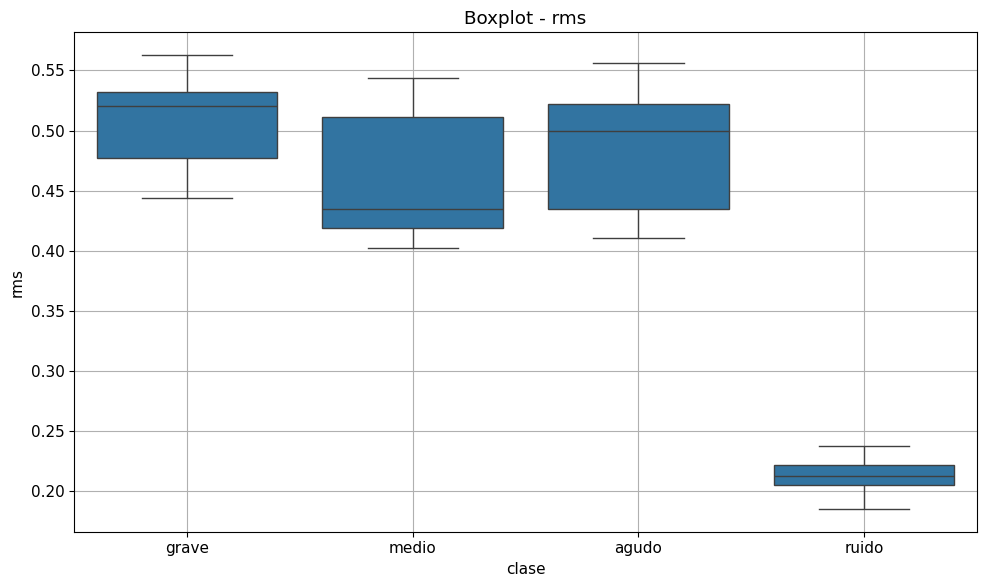

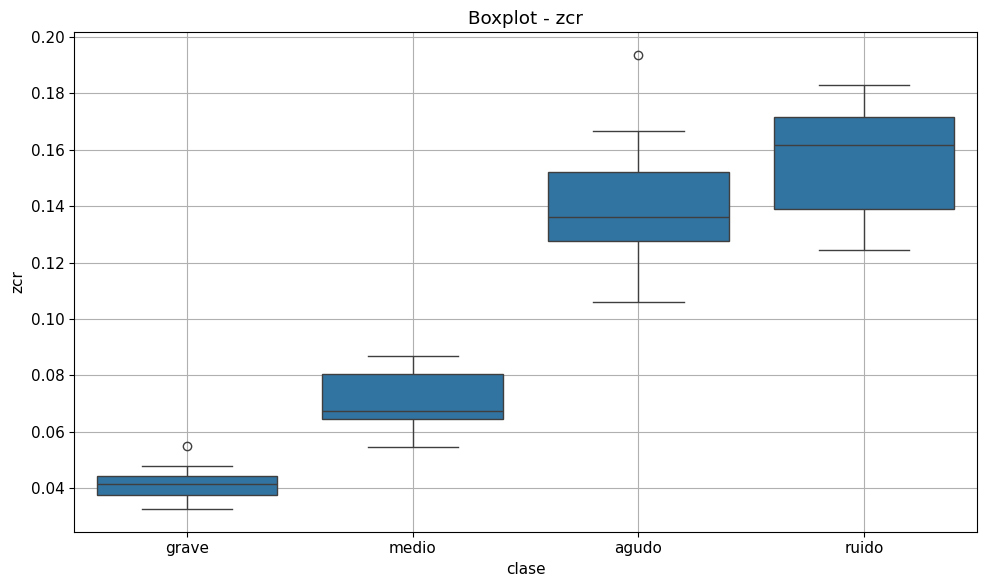

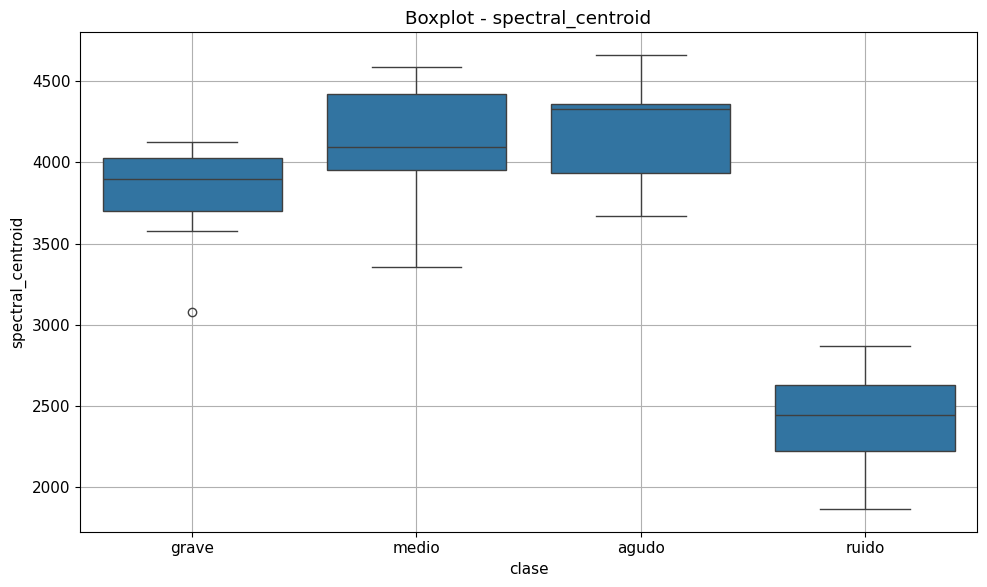

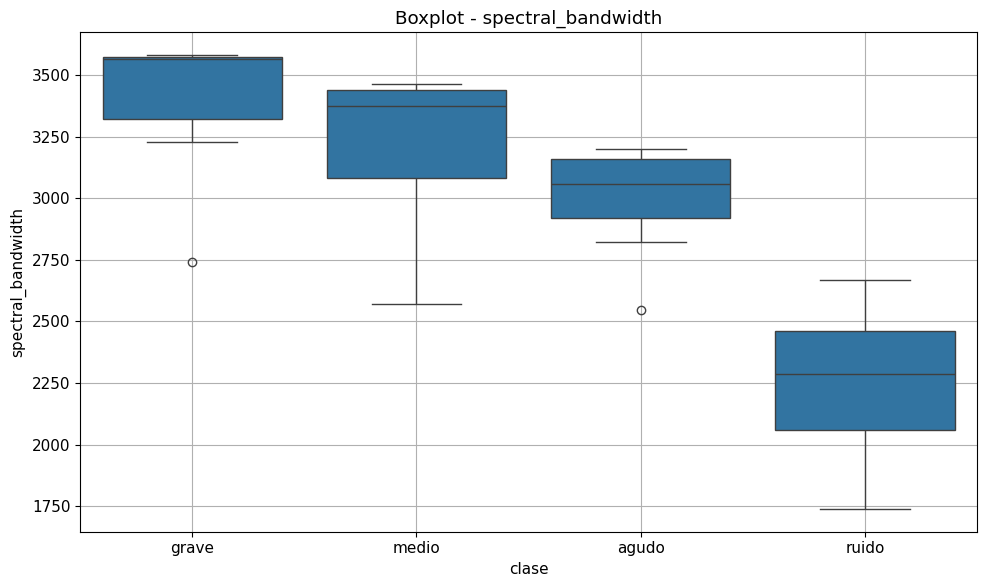

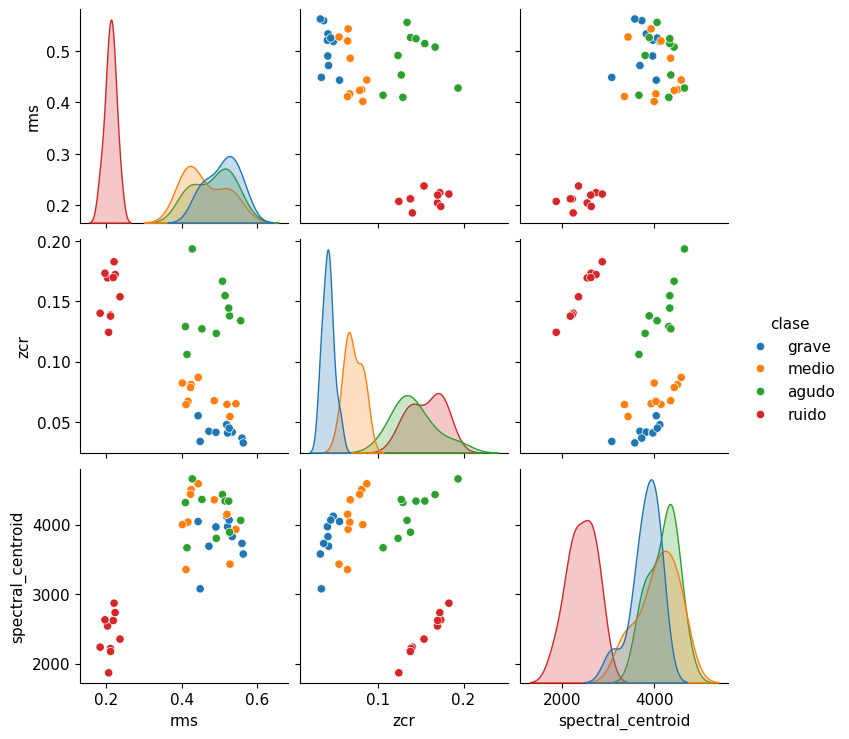

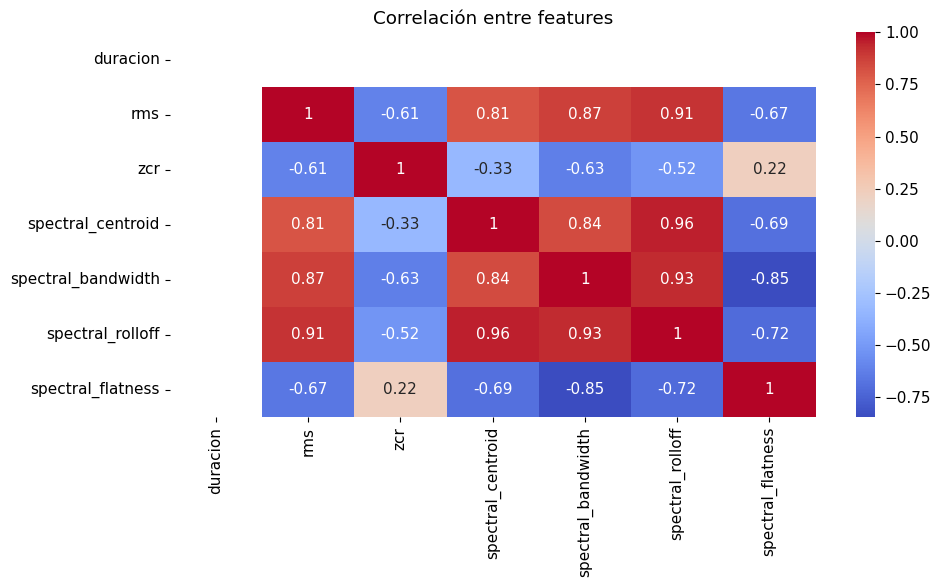


Pares con alta correlación (> 0.7):
rms - spectral_centroid: 0.81
rms - spectral_bandwidth: 0.87
rms - spectral_rolloff: 0.91
spectral_centroid - rms: 0.81
spectral_centroid - spectral_bandwidth: 0.84
spectral_centroid - spectral_rolloff: 0.96
spectral_bandwidth - rms: 0.87
spectral_bandwidth - spectral_centroid: 0.84
spectral_bandwidth - spectral_rolloff: 0.93
spectral_bandwidth - spectral_flatness: -0.85
spectral_rolloff - rms: 0.91
spectral_rolloff - spectral_centroid: 0.96
spectral_rolloff - spectral_bandwidth: 0.93
spectral_rolloff - spectral_flatness: -0.72
spectral_flatness - spectral_bandwidth: -0.85
spectral_flatness - spectral_rolloff: -0.72


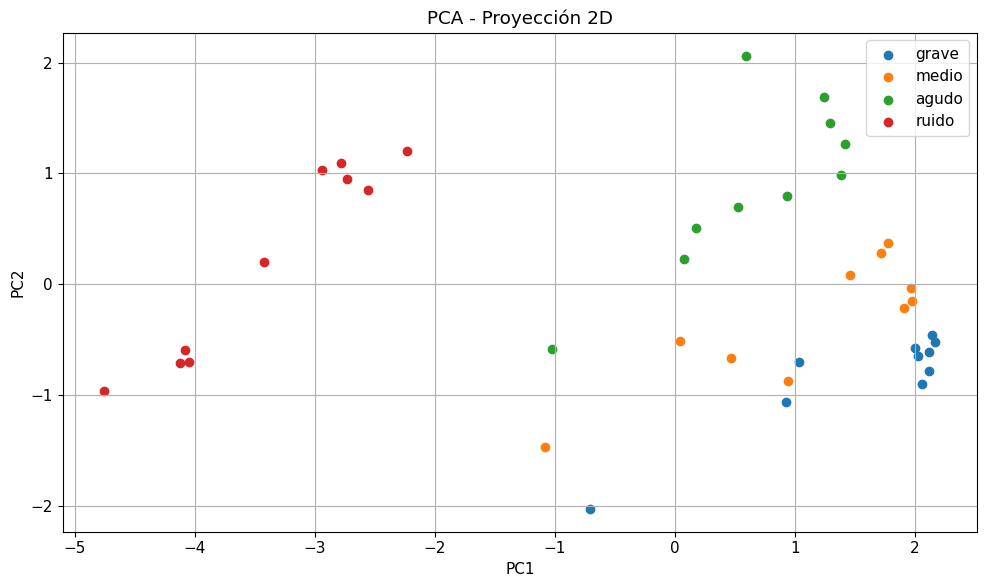


Varianza explicada por cada componente:
[0.76901747 0.14136523]


In [ ]:
# =========================
# EXTRACCION DE FEATURES
# =========================

features_lista = []

for muestra in dataset_procesado:
    audio = muestra['audio']
    sr = muestra['sr']

    features = {
        'clase': muestra['clase'],
        'duracion': len(audio) / sr,
        'rms': np.sqrt(np.mean(audio**2)),
        'zcr': librosa.feature.zero_crossing_rate(audio)[0].mean(),
        'spectral_centroid': librosa.feature.spectral_centroid(y=audio, sr=sr)[0].mean(),
        'spectral_bandwidth': librosa.feature.spectral_bandwidth(y=audio, sr=sr)[0].mean(),
        'spectral_rolloff': librosa.feature.spectral_rolloff(y=audio, sr=sr)[0].mean(),
        'spectral_flatness': librosa.feature.spectral_flatness(y=audio)[0].mean()
    }

    features_lista.append(features)

df_features = pd.DataFrame(features_lista)

print("📊 Features:")
display(df_features.head())


# =========================
# ESTADISTICOS POR CLASE
# =========================

df_stats = df_features.groupby("clase").agg(['mean','std','min','max'])

print("\n📊 Estadísticos descriptivos:")
display(df_stats)


# =========================
# BOXPLOTS
# =========================

features_plot = ['rms', 'zcr', 'spectral_centroid', 'spectral_bandwidth']

for f in features_plot:
    plt.figure()
    sns.boxplot(x='clase', y=f, data=df_features)
    plt.title(f"Boxplot - {f}")
    plt.grid()
    plt.tight_layout()
    plt.show()


# =========================
# PAIRPLOT
# =========================

sns.pairplot(df_features[['rms','zcr','spectral_centroid','clase']], hue='clase')
plt.show()


# =========================
# HEATMAP CORRELACION
# =========================

corr = df_features.drop(columns=['clase']).corr()

plt.figure()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlación entre features")
plt.tight_layout()
plt.show()


# =========================
# ANALISIS CORRELACION
# =========================

print("\nPares con alta correlación (> 0.7):")

for i in corr.columns:
    for j in corr.columns:
        if i != j and abs(corr.loc[i,j]) > 0.7:
            print(f"{i} - {j}: {corr.loc[i,j]:.2f}")


# =========================
# PCA
# =========================

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df_features.drop(columns=['clase'])
y = df_features['clase']

# normalizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# gráfico
plt.figure()
for clase in clases:
    idx = (y == clase)
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=clase)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - Proyección 2D")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# varianza explicada
print("\nVarianza explicada por cada componente:")
print(pca.explained_variance_ratio_)

In [ ]:
from IPython.display import Markdown, display

display(Markdown("""
### Conclusiones sobre separabilidad

- Las features extraídas permiten diferenciar las clases de manera efectiva.
- El centroid y el bandwidth son altamente discriminativos, ya que reflejan el contenido frecuencial.
- La ZCR ayuda a diferenciar señales de alta frecuencia (agudos y ruido).
- Se observan algunas correlaciones altas entre features espectrales, indicando posible redundancia.
- El PCA muestra una separación clara entre clases, especialmente entre ruido y señales armónicas.
- En general, las clases son separables en el espacio de características, lo que indica que el dataset es adecuado para tareas de clasificación.
"""))


### Conclusiones sobre separabilidad

- Las features extraídas permiten diferenciar las clases de manera efectiva.
- El centroid y el bandwidth son altamente discriminativos, ya que reflejan el contenido frecuencial.
- La ZCR ayuda a diferenciar señales de alta frecuencia (agudos y ruido).
- Se observan algunas correlaciones altas entre features espectrales, indicando posible redundancia.
- El PCA muestra una separación clara entre clases, especialmente entre ruido y señales armónicas.
- En general, las clases son separables en el espacio de características, lo que indica que el dataset es adecuado para tareas de clasificación.
